# NB3 — DPO Training (the main event)

**Stack:** TRL `DPOTrainer` + `DPOConfig(beta=0.1, lr=5e-7)` from deck §5.2.
Maps to deck §3 (DPO derivation), §3.4 (failure modes — read closely!), §5.2 (TRL impl).

> **Mục tiêu:** train DPO adapter on top of NB1 SFT-mini. Plot reward curves
> (cả `chosen_rewards` và `rejected_rewards`). Save adapter to `adapters/dpo/`.
>
> Đây là **the** notebook quan trọng nhất của lab — 25/100 pts đến từ đây.
> Đặc biệt là: **plot cả 2 curve riêng biệt**, không chỉ reward gap (deck §3.4).

## 0. Setup

In [1]:
import os
from pathlib import Path

COMPUTE_TIER = os.environ.get("COMPUTE_TIER", "T4").upper()

if COMPUTE_TIER == "T4":
    BASE_MODEL = "unsloth/Qwen2.5-3B-bnb-4bit"
    MAX_LEN = 512
    MAX_PROMPT_LEN = 256
    PER_DEVICE_BATCH = 1
    GRAD_ACCUM = 8
else:
    BASE_MODEL = "unsloth/Qwen2.5-7B-bnb-4bit"
    MAX_LEN = 1024
    MAX_PROMPT_LEN = 512
    PER_DEVICE_BATCH = 1
    GRAD_ACCUM = 4

# Hyperparameters from deck §5.2 lines 849–886
BETA = float(os.environ.get("DPO_BETA", "0.1"))
LR = float(os.environ.get("DPO_LR", "5e-7"))
EPOCHS = int(os.environ.get("DPO_EPOCHS", "1"))

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SFT_PATH = REPO_ROOT / "adapters" / "sft-mini"
DPO_OUT = REPO_ROOT / "adapters" / "dpo"
PREF_PATH = REPO_ROOT / "data" / "pref" / "train.parquet"

DPO_OUT.mkdir(parents=True, exist_ok=True)

assert SFT_PATH.exists(), f"NB1 must run first — {SFT_PATH} missing"
assert PREF_PATH.exists(), f"NB2 must run first — {PREF_PATH} missing"

print(f"COMPUTE_TIER:    {COMPUTE_TIER}")
print(f"BASE_MODEL:      {BASE_MODEL}")
print(f"DPO hyperparams: beta={BETA}  lr={LR}  epochs={EPOCHS}")
print(f"max_length:      {MAX_LEN}  (prompt={MAX_PROMPT_LEN})")
print(f"effective batch: {PER_DEVICE_BATCH * GRAD_ACCUM}")
print(f"SFT input:       {SFT_PATH}")
print(f"output:          {DPO_OUT}")

COMPUTE_TIER:    T4
BASE_MODEL:      unsloth/Qwen2.5-3B-bnb-4bit
DPO hyperparams: beta=0.1  lr=5e-07  epochs=1
max_length:      512  (prompt=256)
effective batch: 8
SFT input:       /workspace/lab22/adapters/sft-mini
output:          /workspace/lab22/adapters/dpo


In [2]:
import torch

assert torch.cuda.is_available(), "DPO needs a CUDA GPU. See HARDWARE-GUIDE.md."

## 1. Load policy + reference (the VRAM-doubling part)

**Critical:** DPO needs the policy (trainable) AND a frozen reference (no grad).
The reference is the SFT model at step 0; we load it twice. Unsloth's 4-bit base
is shared across copies — only the LoRA adapter differs.

In [3]:
from unsloth import FastLanguageModel
from peft import PeftModel

# Policy — gets new DPO LoRA adapter on top of SFT LoRA
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL,
    max_seq_length=MAX_LEN,
    dtype=torch.float16,
    load_in_4bit=True,
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Load SFT adapter on top of base
model = PeftModel.from_pretrained(model, str(SFT_PATH), is_trainable=True)
print(f"Policy: {model.__class__.__name__} with SFT adapter loaded")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


🦥 Unsloth Zoo will now patch everything to make training faster!


==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA GeForce RTX 3090. Num GPUs = 1. Max memory: 23.586 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Policy: PeftModelForCausalLM with SFT adapter loaded


In [4]:
# Wrap policy with NEW LoRA adapter for DPO updates (don't merge SFT — keep stacked)
# Unsloth re-applies LoRA on top of the existing PeftModel.
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    lora_alpha=32,
    lora_dropout=0.0,
    bias="none",
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    use_gradient_checkpointing=True,
    random_state=42,
    use_rslora=False,
    loftq_config=None,
)
print(f"Trainable params (DPO LoRA): {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Unsloth: Already have LoRA adapters! We shall skip this step.


Trainable params (DPO LoRA): 29,933,568


> **Why no separate `ref_model=` argument?** Modern TRL (≥ 0.12) auto-detects
> PEFT models and uses the *base model without the adapter* as the reference.
> That's the same memory layout: 1 base + 2 adapter sets in VRAM. No deepcopy
> needed.

## 2. Build DPOConfig (deck §5.2 hyperparameters)

In [5]:
from trl import DPOConfig

dpo_config = DPOConfig(
    output_dir=str(DPO_OUT.parent / "dpo-checkpoints"),
    per_device_train_batch_size=PER_DEVICE_BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,
    num_train_epochs=EPOCHS,
    learning_rate=LR,
    beta=BETA,
    max_length=MAX_LEN,
    max_prompt_length=MAX_PROMPT_LEN,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    logging_steps=10,
    save_strategy="no",
    optim="adamw_8bit",
    bf16=False,
    fp16=True,
    seed=42,
    loss_type="sigmoid",         # DPO standard (alternatives: ipo, hinge, kto)
    report_to="none",
)

print(f"DPOConfig: beta={dpo_config.beta}  lr={dpo_config.learning_rate}  loss_type={dpo_config.loss_type}")

DPOConfig: beta=0.1  lr=5e-07  loss_type=sigmoid


## 3. Load preference data

In [6]:
from datasets import Dataset

pref_ds = Dataset.from_parquet(str(PREF_PATH))
print(f"Loaded {len(pref_ds)} preference pairs from {PREF_PATH}")
print(f"Columns: {pref_ds.column_names}")

Loaded 2000 preference pairs from /workspace/lab22/data/pref/train.parquet
Columns: ['prompt', 'chosen', 'rejected']


## 4. Train

In [7]:
from trl import DPOTrainer

trainer = DPOTrainer(
    model=model,
    ref_model=None,                # auto-derived from PEFT base
    args=dpo_config,
    train_dataset=pref_ds,
    tokenizer=tokenizer,
)

In [8]:
train_result = trainer.train()
print(f"\nFinal DPO loss: {train_result.training_loss:.4f}")

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 2,000 | Num Epochs = 1 | Total steps = 250
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)


Step,Training Loss,rewards / chosen,rewards / rejected,rewards / accuracies,rewards / margins,logps / chosen,logps / rejected,logits / chosen,logits / rejected
10,0.885000,-1.077691,-1.058880,0.437500,-0.018811,-395.024323,-281.500397,-1.418746,-1.437112
20,0.907900,-1.149927,-1.125663,0.462500,-0.024263,-433.888824,-347.492004,-1.377490,-1.390716
30,0.742900,-0.859824,-1.147135,0.562500,0.287311,-377.091400,-288.411926,-1.441455,-1.475032
40,0.942200,-1.110359,-1.048681,0.425000,-0.061678,-384.661835,-329.045258,-1.412490,-1.355557
50,0.747500,-0.766845,-1.043418,0.625000,0.276573,-389.616760,-307.529114,-1.451270,-1.485181
60,0.768600,-0.875813,-0.984404,0.500000,0.108591,-390.737244,-341.153687,-1.461095,-1.461953
70,0.722800,-0.725517,-1.038990,0.612500,0.313473,-385.270813,-364.936096,-1.579225,-1.441818
80,0.919400,-1.007255,-1.034046,0.512500,0.026792,-411.047180,-327.737762,-1.397448,-1.501018
90,0.859800,-0.853334,-0.983912,0.587500,0.130579,-430.171967,-319.317200,-1.482412,-1.440242
100,0.779900,-0.903364,-1.105452,0.550000,0.202087,-363.060394,-307.242767,-1.404162,-1.384317



Final DPO loss: 0.7807


## 5. Plot reward curves — THE diagnostic

**Read deck §3.4 before interpreting these.** A growing reward gap can come from:
- **(intended)** chosen reward going up + rejected staying flat
- **(intended)** chosen rising slowly + rejected falling fast
- **(likelihood displacement)** chosen reward going *down* + rejected falling faster

The third case is what Razin et al. 2024 documented. It's not a bug, but it
tells you the model is finding a way to widen the gap that doesn't necessarily
improve actual chosen probability.

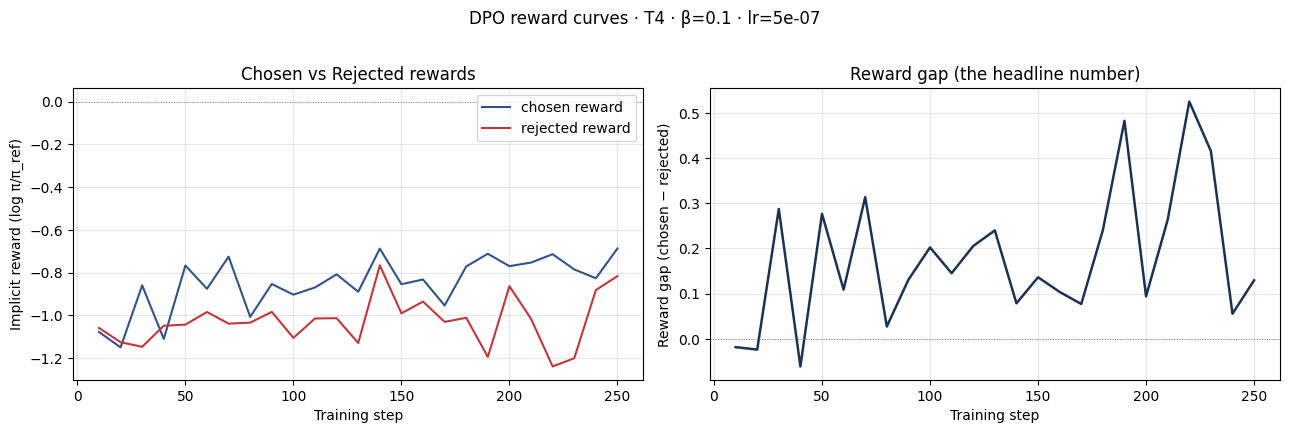

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

logs = pd.DataFrame(trainer.state.log_history)
logs = logs[logs["loss"].notna() if "loss" in logs.columns else logs.index].copy()

# TRL DPO logs include rewards/chosen, rewards/rejected, rewards/margins, kl
chosen_col = "rewards/chosen" if "rewards/chosen" in logs.columns else None
rejected_col = "rewards/rejected" if "rewards/rejected" in logs.columns else None

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

if chosen_col and rejected_col:
    axes[0].plot(logs["step"], logs[chosen_col], label="chosen reward", color="#2e548a", linewidth=1.5)
    axes[0].plot(logs["step"], logs[rejected_col], label="rejected reward", color="#c83538", linewidth=1.5)
    axes[0].axhline(0, color="#888", linestyle=":", linewidth=0.7)
    axes[0].set_xlabel("Training step")
    axes[0].set_ylabel("Implicit reward (log π/π_ref)")
    axes[0].set_title("Chosen vs Rejected rewards")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    gap = logs[chosen_col] - logs[rejected_col]
    axes[1].plot(logs["step"], gap, color="#1a3355", linewidth=1.8)
    axes[1].axhline(0, color="#888", linestyle=":", linewidth=0.7)
    axes[1].set_xlabel("Training step")
    axes[1].set_ylabel("Reward gap (chosen − rejected)")
    axes[1].set_title("Reward gap (the headline number)")
    axes[1].grid(True, alpha=0.3)
else:
    axes[0].text(0.5, 0.5, "No reward columns in trainer.state.log_history.\nLikely TRL version mismatch.",
                 ha="center", va="center", transform=axes[0].transAxes)
    axes[1].text(0.5, 0.5, "—", ha="center", va="center", transform=axes[1].transAxes)

fig.suptitle(f"DPO reward curves · {COMPUTE_TIER} · β={BETA} · lr={LR}", y=1.02)
fig.tight_layout()

screenshot_dir = REPO_ROOT / "submission" / "screenshots"
screenshot_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(screenshot_dir / "03-dpo-reward-curves.png", dpi=120, bbox_inches="tight")
plt.show()

### 5a. Failure-mode self-check

Read this cell carefully — it tells you which kind of "reward gap up" you got.

In [10]:
if chosen_col and rejected_col and len(logs) >= 5:
    last_chosen = logs[chosen_col].iloc[-5:].mean()
    last_rejected = logs[rejected_col].iloc[-5:].mean()
    last_gap = last_chosen - last_rejected
    first_chosen = logs[chosen_col].iloc[:5].mean()

    chosen_delta = last_chosen - first_chosen

    print(f"END  chosen reward:    {last_chosen:+.3f}")
    print(f"END  rejected reward:  {last_rejected:+.3f}")
    print(f"END  reward gap:       {last_gap:+.3f}")
    print()

    if last_gap < 0:
        print("✗ FAILURE: reward gap went NEGATIVE. DPO did the opposite of what you wanted.")
        print("  Likely causes: data quality (chosen/rejected swapped?), beta too high, lr too low.")
    elif chosen_delta < -0.5 and last_gap > 0:
        print("⚠  LIKELIHOOD DISPLACEMENT (deck §3.4):")
        print(f"   Reward gap is positive ({last_gap:+.3f}) — good!")
        print(f"   But chosen reward FELL by {chosen_delta:+.3f} during training.")
        print("   The gap grew because rejected fell faster than chosen.")
        print("   Document this in REFLECTION § 3 — it's a teachable moment, not a bug.")
    elif chosen_delta > 0 and last_gap > 0:
        print("✓ INTENDED: chosen reward UP and gap positive. Classic DPO success.")
    else:
        print("?  AMBIGUOUS: weak chosen movement + positive gap. Try longer training or higher lr.")

END  chosen reward:    -0.753
END  rejected reward:  -1.031
END  reward gap:       +0.278

✓ INTENDED: chosen reward UP and gap positive. Classic DPO success.


## 6. Save adapter

In [11]:
trainer.model.save_pretrained(str(DPO_OUT))
tokenizer.save_pretrained(str(DPO_OUT))
print(f"Saved DPO adapter to {DPO_OUT}")

# Save the headline metrics for verify.py + REFLECTION
import json

metrics = {
    "compute_tier": COMPUTE_TIER,
    "base_model": BASE_MODEL,
    "beta": BETA,
    "lr": LR,
    "epochs": EPOCHS,
    "final_train_loss": float(train_result.training_loss),
    "end_chosen_reward": float(last_chosen) if chosen_col else None,
    "end_rejected_reward": float(last_rejected) if rejected_col else None,
    "end_reward_gap": float(last_gap) if chosen_col and rejected_col else None,
}
(DPO_OUT / "dpo_metrics.json").write_text(json.dumps(metrics, indent=2))
print(f"Wrote metrics to {DPO_OUT / 'dpo_metrics.json'}")

Saved DPO adapter to /workspace/lab22/adapters/dpo
Wrote metrics to /workspace/lab22/adapters/dpo/dpo_metrics.json


## 7. Vibe-coding callout

Now's the time for the **β experiment** if you want the +6 rigor add-on.

`make beta-sweep` runs this notebook 3 times with `DPO_BETA ∈ {0.05, 0.1, 0.5}`
and saves to `adapters/dpo-b{0.05,0.1,0.5}/`. Plot the results yourself:

```python
import json
import matplotlib.pyplot as plt
from pathlib import Path

results = []
for d in sorted((REPO_ROOT / "adapters").glob("dpo-b*")):
    m = json.loads((d / "dpo_metrics.json").read_text())
    results.append((m["beta"], m["end_reward_gap"]))
# plot β vs reward_gap
```

**Think-hard zone:** what's the *expected* shape of the β-vs-reward-gap curve?
Hypothesize before you look at the data. (Hint: deck §3.3.)

**Next:** NB4 — qualitative side-by-side comparison.